# Week 4 Segmentation and Clustering

## Objective

This notebook applies K-Means and DBSCAN clustering to synthetic Aido Rover telemetry in order to identify distinct operational modes. It also applies K-Means to synthetic Aido Humanoid joint-velocity data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load the Aido Rover Dataset

In [2]:
df = pd.read_csv("../data/synthetic_rover_data.csv")

df.head()

print("Dataset shape:", df.shape)
print(df.columns)

Dataset shape: (12000, 11)
Index(['timestamp', 'latitude', 'longitude', 'lidar_distance', 'battery_soc',
       'wheel_torque_1', 'wheel_torque_2', 'wheel_torque_3', 'wheel_torque_4',
       'temperature', 'status'],
      dtype='str')


## 2. Data Quality Check

In [3]:
quality_report = pd.DataFrame({
    "data_type": df.dtypes.astype(str),
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().mean() * 100).round(2)
})

quality_report

print("Duplicate rows:", df.duplicated().sum())

print("Battery below 0:", (df["battery_soc"] < 0).sum())
print("Battery above 100:", (df["battery_soc"] > 100).sum())
print("Negative LiDAR values:", (df["lidar_distance"] < 0).sum())

Duplicate rows: 0
Battery below 0: 0
Battery above 100: 112
Negative LiDAR values: 1


**Data quality finding:** GPS columns contain simulated missing values. These columns will not be used directly in clustering because missing values cannot be passed into K-Means or DBSCAN without preprocessing.

In [4]:
torque_columns = [
    "wheel_torque_1",
    "wheel_torque_2",
    "wheel_torque_3",
    "wheel_torque_4"
]

df["avg_torque"] = df[torque_columns].mean(axis=1)

df["torque_imbalance"] = df[torque_columns].std(axis=1)

df[
    [
        "battery_soc",
        "lidar_distance",
        "temperature",
        "avg_torque",
        "torque_imbalance"
    ]
].head()

,battery_soc,lidar_distance,temperature,avg_torque,torque_imbalance
0,101.499580,6.214978,26.144969,28.633617,1.548972
1,101.481014,2.904787,27.499129,29.351270,3.066189
2,98.925882,30.000000,18.317683,32.146297,2.308149
3,100.572100,5.984263,23.060746,30.009229,8.859958
4,102.499250,6.773406,23.604358,31.505002,3.420476


In [5]:
feature_columns = [
    "battery_soc",
    "lidar_distance",
    "temperature",
    "avg_torque",
    "torque_imbalance"
]

X = df[feature_columns].copy()
X = X.dropna()

print("Rows used for clustering:", len(X))

Rows used for clustering: 12000


In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

**Preprocessing note:** StandardScaler was applied so that features measured in different units contribute more equally to the clustering result.

## 3. K-Means Clustering

### 3.1 Elbow Method

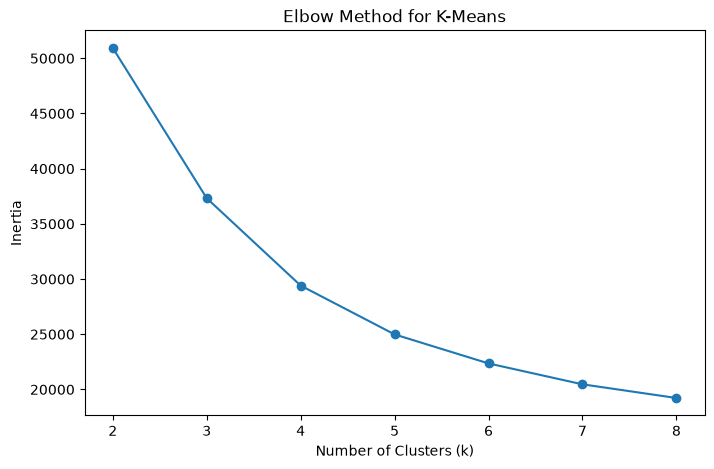

In [7]:
inertias = []
k_values = range(2, 9)

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")

plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.show()

**Finding:** The elbow plot is used to identify the point where adding more clusters produces only a small reduction in inertia.

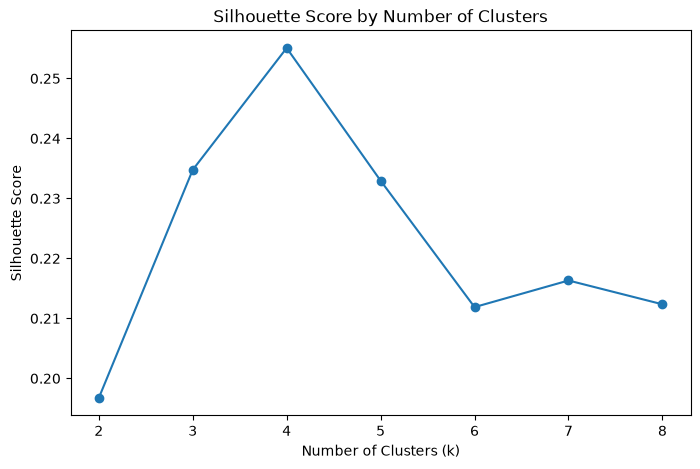

Best k: 4
Best silhouette score: 0.2551


In [8]:
silhouette_scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker="o")

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))
plt.show()

best_k = list(k_values)[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)

print("Best k:", best_k)
print("Best silhouette score:", round(best_score, 4))

In [9]:
chosen_k = 4

kmeans = KMeans(
    n_clusters=chosen_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

In [10]:
clustered_df = df.loc[X.index].copy()

clustered_df["kmeans_cluster"] = kmeans_labels

clustered_df.head()

,timestamp,latitude,longitude,lidar_distance,battery_soc,wheel_torque_1,wheel_torque_2,wheel_torque_3,wheel_torque_4,temperature,status,avg_torque,torque_imbalance,kmeans_cluster
0,2026-07-01 00:00:00,43.072474,-89.400668,6.214978,101.499580,30.498199,27.707335,27.063768,29.265164,26.144969,Normal,28.633617,1.548972,2
1,2026-07-01 00:01:00,43.073330,-89.401182,2.904787,101.481014,31.638698,30.454532,24.826910,30.484939,27.499129,Fault,29.351270,3.066189,2
2,2026-07-01 00:02:00,43.073878,-89.401202,30.000000,98.925882,34.718033,29.222000,31.708100,32.937053,18.317683,Normal,32.146297,2.308149,3
3,2026-07-01 00:03:00,43.072368,-89.402706,5.984263,100.572100,36.340124,17.562884,36.368883,29.765023,23.060746,Normal,30.009229,8.859958,2
4,2026-07-01 00:04:00,43.073881,-89.402177,6.773406,102.499250,30.074116,27.359921,33.890405,34.695564,23.604358,Normal,31.505002,3.420476,2


In [11]:
clustered_df["kmeans_cluster"].value_counts().sort_index()

kmeans_cluster
0    5598
1     581
2    5582
3     239
Name: count, dtype: int64

In [12]:
cluster_profile = clustered_df.groupby(
    "kmeans_cluster"
)[
    [
        "battery_soc",
        "lidar_distance",
        "temperature",
        "avg_torque",
        "torque_imbalance"
    ]
].mean().round(2)

cluster_profile

,battery_soc,lidar_distance,temperature,avg_torque,torque_imbalance
kmeans_cluster,,,,,
0,40.02,8.07,24.00,30.03,4.53
1,59.96,8.04,24.08,69.68,10.60
2,80.03,7.94,24.13,30.02,4.67
3,59.75,30.00,23.80,33.15,4.68


In [13]:
dominant_status = clustered_df.groupby(
    "kmeans_cluster"
)["status"].agg(lambda x: x.mode().iloc[0])

dominant_status

kmeans_cluster
0    Normal
1    Normal
2    Normal
3    Normal
Name: status, dtype: str

## Cluster Interpretation

### Cluster 0 – Low Battery Operation
Robots in this cluster have relatively low battery levels while maintaining normal torque output. These robots may require battery charging soon.

### Cluster 1 – High Load Operation
This cluster has significantly higher average wheel torque, suggesting robots are performing heavier operational tasks.

### Cluster 2 – Normal Patrol
Robots maintain high battery levels with low torque demand, representing normal and energy-efficient operation.

### Cluster 3 – Long Distance Detection
This cluster is characterized by unusually high LiDAR distance readings, indicating operation in open environments or long-range sensing conditions.

In [14]:
from sklearn.decomposition import PCA

In [15]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

X_pca.shape

(12000, 2)

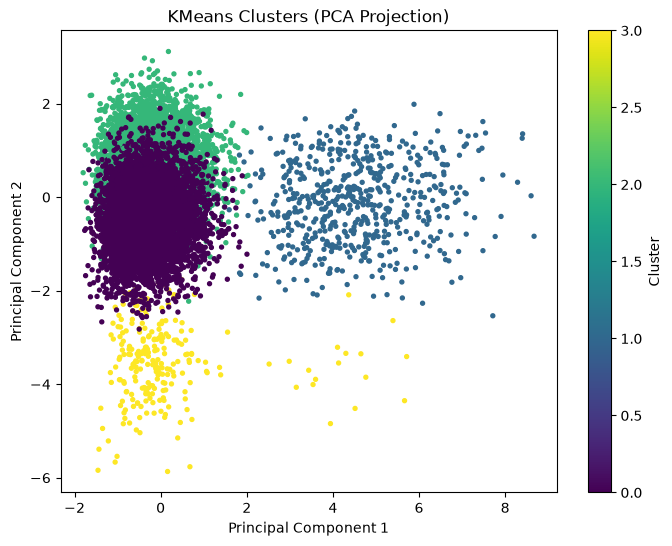

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans_labels,
    cmap="viridis",
    s=8
)

plt.title("KMeans Clusters (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

In [17]:
from sklearn.cluster import DBSCAN

In [18]:
dbscan = DBSCAN(
    eps=0.6,
    min_samples=10
)

dbscan_labels = dbscan.fit_predict(X_scaled)

In [19]:
import numpy as np

np.unique(dbscan_labels)

array([-1,  0,  1,  2])

In [20]:
import pandas as pd

pd.Series(dbscan_labels).value_counts().sort_index()

-1     1196
 0    10760
 1       26
 2       18
Name: count, dtype: int64

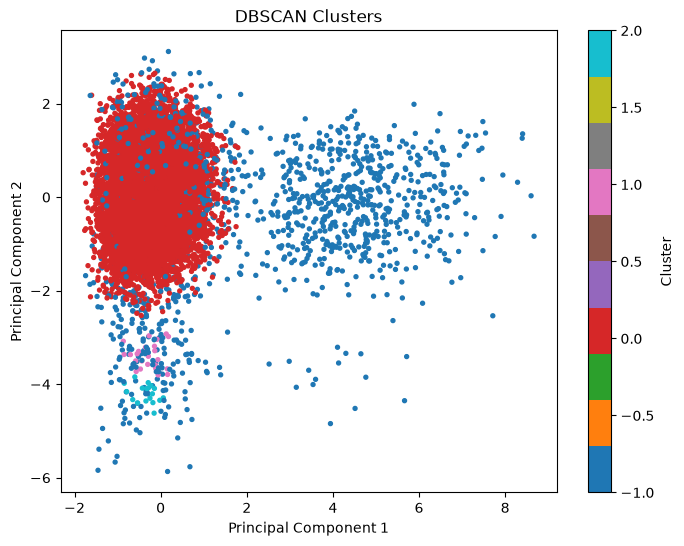

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=dbscan_labels,
    cmap="tab10",
    s=8
)

plt.title("DBSCAN Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

## DBSCAN Analysis

DBSCAN was applied to detect density-based groups without specifying the number of clusters in advance.

The algorithm identified the major operational group while labeling sparse observations as noise. These noise points may represent unusual robot behaviors or potential anomalies.

Compared with K-Means, DBSCAN is more suitable for anomaly detection because it can naturally identify isolated observations.